In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

if project=='realBathy':
    if ed == 'run7/' or ed == 'run5/' or ed == 'run4/':
        ds=xr.open_dataset(str(location) + 'dynDiagSmag3.nc')
        ds4=xr.open_dataset(str(location) + 'dynDiagSmag4.nc')
        dsGV=xr.open_dataset(str(location) + 'dynDiagGridVisc.nc') #Instead of ViscAh I use viscAhGrid=0.03
        dsGVSmag=xr.open_dataset(str(location) + 'dynDiagGridViscSmag.nc') #Instead of ViscAh I use viscAhGrid=0.03 and Smag 3
        dsBiHarm=xr.open_dataset(str(location) + 'dynDiagBiharm.nc') #Instead of ViscAh I use viscA4Grid=0.01 and SmagC2 1 w/o vertical viscosity
        dsBiHarmC4=xr.open_dataset(str(location) + 'dynDiagBiharmC4.nc') #Instead of ViscAh I use viscAhGrid=0.01 and SmagC4 4 w/o vertical viscosity
        dsBiHarmC4C2=xr.open_dataset(str(location) + 'dynDiagBiharmC4C2.nc') #Instead of ViscAh I use viscAhGrid=0.03 and viscA4Grid=0.03 and SmagC4 and SmagC2 1
        dsBiHarmGrid4C2=xr.open_dataset(str(location) + 'dynDiagBiharmGrid4C2.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1
        dsBiHarmNotel=xr.open_dataset(str(location) + 'dynDiagBiharmNotel.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1 and I have no telescopic boundaries
        dshfac03=xr.open_dataset(str(location) + 'dynDiaghfac03.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1 and I have no telescopic boundaries and hfac is 0.3 instead of 0.1
        dsleith=xr.open_dataset(str(location) + 'dynDiagleith.nc') #Using Leith viscosity as 1 and viscA4Grid=0.03
        dsleithMax=xr.open_dataset(str(location) + 'dynDiagleithWithMaxDef.nc') #Using Leith viscosity as 3 and viscA4Grid=0.03, also adding the parameters defining maximum viscAh and ViscA4 as 1
        dsNoSideDrag=xr.open_dataset(str(location) + 'dynDiagNodragSides.nc') #Going back to basics, but making sure the side drag is of by turning the side drag coef to 0
        dsParabolic=xr.open_dataset(str(location) + 'dynDiagParabolic.nc') #Parabolic bottom
        dsLeithD=xr.open_dataset(str(location) + 'dynDiagLeithD.nc') #Using the full leith with coeff leithD=coeff leith=1
        dsLeithD2=xr.open_dataset(str(location) + 'dynDiagLeithD2.nc') #Using the full leith with coeff leithD=coeff leith=2
        dsLeithD3=xr.open_dataset(str(location) + 'dynDiagLeithD3.nc') #Using the full leith with coeff leithD=coeff leith=3
        dsLeithD3Ar3=xr.open_dataset(str(location) + 'dynDiagLeithD3ViscAr1-3.nc') #Using the full leith with coeff leithD=coeff leith=3 and viscAr being 1e-3
        dsLeithD3A4=xr.open_dataset(str(location) + 'dynDiagLeithD3ViscA4.nc') #Using the full leith with coeff leithD=coeff leith=3 and viscAr being 1e-3 and adding biharmonic viscosity grid 0.05
        dsLeithD3AhHigh=xr.open_dataset(str(location) + 'dynDiagLeithD3ViscAhHigh.nc') #Using the full leith with coeff leithD=coeff leith=3 and viscAr being 1e-3 and adding biharmonic viscosity grid 0.05 and viscAh=1
        dsNoC=xr.open_dataset(str(location) + 'dynDiagNoC.nc') #No Parameterization, NO ROTATION
        dsDrag=xr.open_dataset(str(location) + 'dynDiagDrag.nc') #No Parameterization, DRAG
        dsDragBot=xr.open_dataset(str(location) + 'dynDiagDragBot.nc') #No Parameterization, bottom drag
    else:
        for i in np.arange(10,60,10):
            var='dynDiag'+str(i)
            if i==10:
                ds=xr.open_dataset(str(location) +  str(var) + '.nc')
            else:
                ds=ds.merge(xr.open_dataset(str(location) +  str(var) + '.nc'))
else:
    var='dynDiag'
    ds=xr.open_dataset(str(location) +  str(var) + '.nc')


#varS='surfDiag'

#dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='gridSmag3'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
if project=='realBathy':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=2
    OBendx=-2

In [3]:
directory='/Users/ameliameggo/Proyecto/Codigo/NGC/longerDomain'
ed='run1/'
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
dsflux=xr.open_dataset(str(location) + 'dynDiag.nc')

In [4]:
project='realBathy'
ed='run5/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
dsWVEL=xr.open_dataset(str(location) + 'WVEL.nc')

ed='run6/'
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
dsRun6=xr.open_dataset(str(location) + 'dynDiag.nc')

In [5]:
ds=xr.open_dataset(str(location) + 'dynDiagSmag3.nc')
        ds4=xr.open_dataset(str(location) + 'dynDiagSmag4.nc')
        dsGV=xr.open_dataset(str(location) + 'dynDiagGridVisc.nc') #Instead of ViscAh I use viscAhGrid=0.03
        dsGVSmag=xr.open_dataset(str(location) + 'dynDiagGridViscSmag.nc') #Instead of ViscAh I use viscAhGrid=0.03 and Smag 3
        dsBiHarm=xr.open_dataset(str(location) + 'dynDiagBiharm.nc') #Instead of ViscAh I use viscA4Grid=0.01 and SmagC2 1 w/o vertical viscosity
        dsBiHarmC4=xr.open_dataset(str(location) + 'dynDiagBiharmC4.nc') #Instead of ViscAh I use viscAhGrid=0.01 and SmagC4 4 w/o vertical viscosity
        dsBiHarmC4C2=xr.open_dataset(str(location) + 'dynDiagBiharmC4C2.nc') #Instead of ViscAh I use viscAhGrid=0.03 and viscA4Grid=0.03 and SmagC4 and SmagC2 1
        dsBiHarmGrid4C2=xr.open_dataset(str(location) + 'dynDiagBiharmGrid4C2.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1
        dsBiHarmNotel=xr.open_dataset(str(location) + 'dynDiagBiharmNotel.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1 and I have no telescopic boundaries
        dshfac03=xr.open_dataset(str(location) + 'dynDiaghfac03.nc') #Instead of ViscAh I use SmagC2=4 and viscA4Grid=0.1 and I have no telescopic boundaries and hfac is 0.3 instead of 0.1
        dsleith=xr.open_dataset(str(location) + 'dynDiagleith.nc') #Using Leith viscosity as 1 and viscA4Grid=0.03
        dsleithMax=xr.open_dataset(str(location) + 'dynDiagleithWithMaxDef.nc') #Using Leith viscosity as 3 and viscA4Grid=0.03, also adding the parameters defining maximum viscAh and ViscA4 as 1
        dsNoSideDrag=xr.open_dataset(str(location) + 'dynDiagNodragSides.nc') #Going back to basics, but making sure the side drag is of by turning the side drag coef to 0
        dsParabolic=xr.open_dataset(str(location) + 'dynDiagParabolic.nc') #Parabolic bottom
        dsLeithD=

IndentationError: unexpected indent (2098305467.py, line 2)

In [6]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 3),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [7]:
listDs=[dsWVEL,ds,ds4,dsGV,dsGVSmag,dsBiHarm,dsBiHarmC4,dsBiHarmC4C2,dsBiHarmGrid4C2,dsBiHarmNotel,dshfac03,dsleith,dsleithMax,dsLeithD,dsLeithD2,dsLeithD3,dsLeithD3Ar3,dsLeithD3A4,dsLeithD3AhHigh]

In [8]:
out=np.zeros((2,len(listDs)))
for i in range(len(listDs)):
    out[0,i]=np.max(np.abs(listDs[i].WVEL[:2,:,:,-2].values-listDs[i].WVEL[:2,:,:,-3].values))
    out[1,i]=np.max(np.abs(listDs[i].WVEL[:2,:,:,1].values-listDs[i].WVEL[:2,:,:,2].values))

In [9]:
print(out[0])

[0.00072161 0.00048219 0.00043357 0.00060421 0.00043928 0.00138944
 0.00094366 0.00048419 0.00045012 0.0011353  0.00112361 0.00121217
 0.00121217 0.00039263 0.00036771 0.00033437 0.00032458 0.00029454
 0.00028729]


In [10]:
print(out[1])

[0.00032616 0.00028341 0.00025946 0.00026276 0.00021284 0.00073955
 0.0003815  0.00023728 0.00025441 0.00039132 0.00045286 0.00040293
 0.00040293 0.00020303 0.00020064 0.00019344 0.00018057 0.00016315
 0.00015832]


In [11]:
np.mean(dsLeithD.WVEL[:2,:,OB:OBend,OBx:OBendx].values)

np.float32(3.173864e-07)

In [12]:
np.max(dsLeithD.WVEL[:2,:,:,-2].values-dsLeithD.WVEL[:2,:,:,-3].values)

np.float32(0.00014403909)

In [13]:
np.max(dsLeithD2.WVEL[:2,:,:,-2].values-dsLeithD2.WVEL[:2,:,:,-3].values)

np.float32(0.0001427095)

In [14]:
np.max(dsLeithD3.WVEL[:2,:,:,-2].values-dsLeithD3.WVEL[:2,:,:,-3].values)

np.float32(0.00014033796)

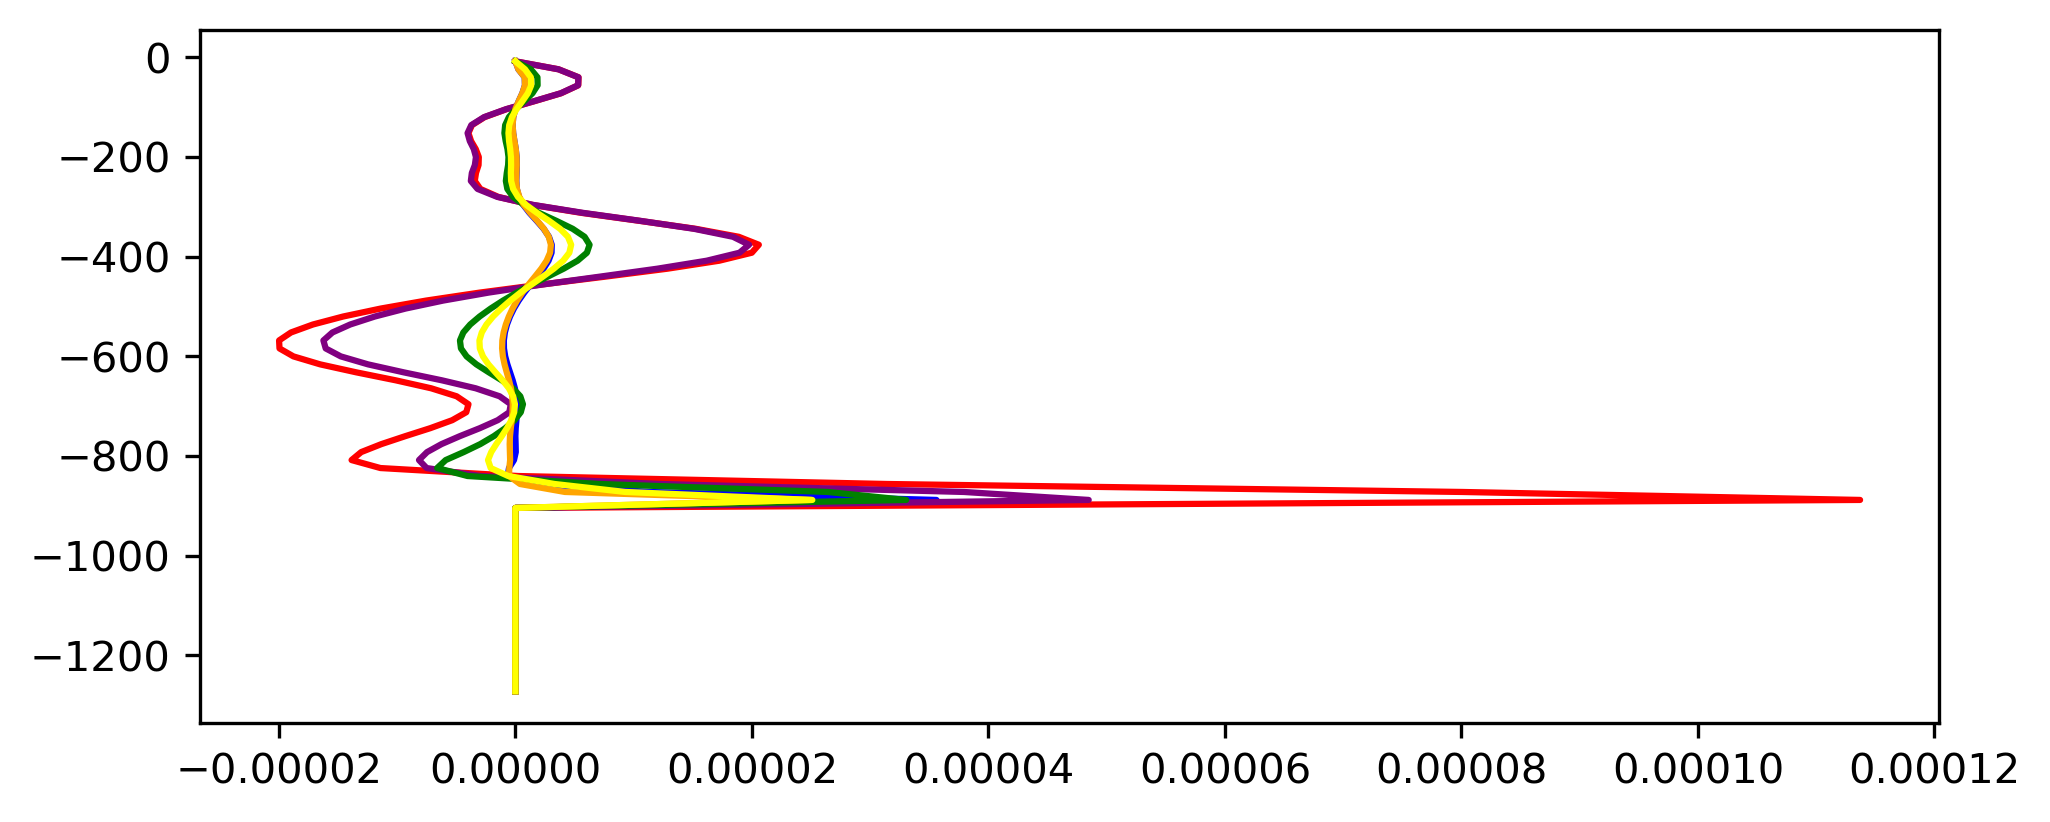

In [15]:
tin=len(dsLeithD.WVEL[:,0,0,0])-1
#plt.plot(dsWVEL.WVEL[tin,:,100,1].values,dsG.Z,'blue')
plt.plot(dsWVEL.WVEL[1,:,100,1].values,dsG.Z,'red')
plt.plot(dsWVEL.WVEL[1,:,100,2].values,dsG.Z,'blue')
#plt.plot(dsLeithD2.WVEL[tin,:,100,1].values,dsG.Z,'orange')
plt.plot(dsDragBot.WVEL[1,:,100,1].values,dsG.Z,'purple')
plt.plot(dsDrag.WVEL[1,:,100,1].values,dsG.Z,'green')
plt.plot(dsDragBot.WVEL[1,:,100,2].values,dsG.Z,'orange')
plt.plot(dsDrag.WVEL[1,:,100,2].values,dsG.Z,'yellow')

In [16]:
ed='run7/'

In [17]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 24),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

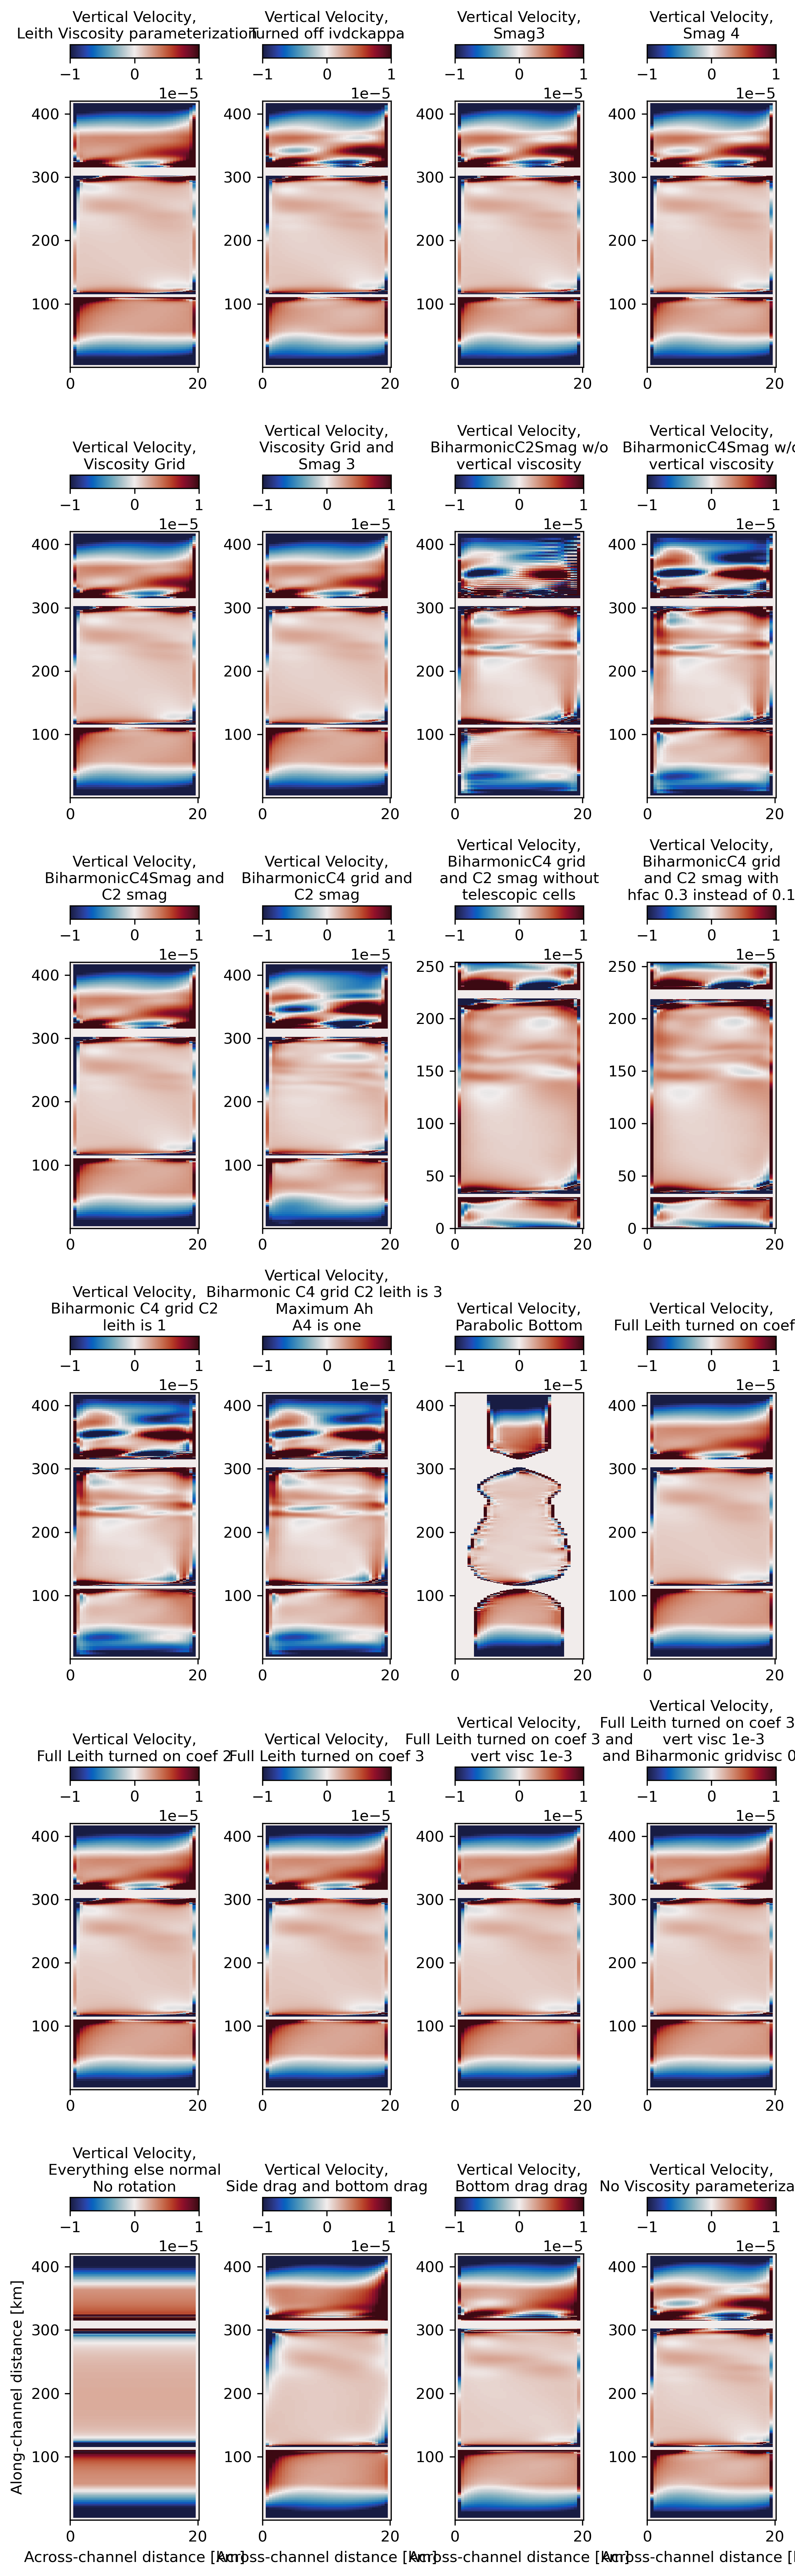

In [19]:
fig,ax=plt.subplots(6,4)
vmax=0.00001
vmin=-0.00001
tin=1
dep=28
cax=ax[5,3].pcolormesh(dsG.X/1000,dsG.Y/1000,dsWVEL.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[5,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nNo Viscosity parameterization')

cax2=ax[0,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsRun6.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[0,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nTurned off ivdckappa')

cax1=ax[0,2].pcolormesh(dsG.X/1000,dsG.Y/1000,ds.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[0,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax1, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nSmag3')

cax2=ax[0,3].pcolormesh(dsG.X/1000,dsG.Y/1000,ds4.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[0,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nSmag 4')


cax2=ax[1,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsGV.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[1,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nViscosity Grid')


cax2=ax[1,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsGVSmag.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[1,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nViscosity Grid and\nSmag 3')

cax2=ax[1,2].pcolormesh(dsG.X/1000,dsG.Y/1000,dsBiHarm.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[1,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC2Smag w/o\nvertical viscosity')

cax2=ax[1,3].pcolormesh(dsG.X/1000,dsG.Y/1000,dsBiHarmC4.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[1,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC4Smag w/o\nvertical viscosity')

cax2=ax[2,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsBiHarmC4C2.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[2,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC4Smag and\nC2 smag')

cax2=ax[2,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsBiHarmGrid4C2.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[2,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC4 grid and\nC2 smag')

cax2=ax[2,2].pcolormesh(dsBiHarmNotel.X/1000,dsBiHarmNotel.Y/1000,dsBiHarmNotel.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[2,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC4 grid \nand C2 smag without\ntelescopic cells')

cax2=ax[2,3].pcolormesh(dshfac03.X/1000,dshfac03.Y/1000,dshfac03.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[2,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonicC4 grid\nand C2 smag with\nhfac 0.3 instead of 0.1')

cax2=ax[3,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsleith.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[3,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonic C4 grid C2\nleith is 1')

cax2=ax[3,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsleithMax.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[3,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nBiharmonic C4 grid C2 leith is 3 \nMaximum Ah \nA4 is one')

cax2=ax[3,2].pcolormesh(dsG.X/1000,dsG.Y/1000,dsParabolic.WVEL[tin,dep,:,:].values,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[3,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nParabolic Bottom')

cax2=ax[3,3].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[3,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nFull Leith turned on coef 1')

cax2=ax[4,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD2.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[4,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nFull Leith turned on coef 2')

cax2=ax[4,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD3.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[4,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nFull Leith turned on coef 3')

cax2=ax[4,2].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD3Ar3.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[4,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nFull Leith turned on coef 3 and\n vert visc 1e-3')

cax2=ax[4,3].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD3A4.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[4,3])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nFull Leith turned on coef 3and\n vert visc 1e-3\nand Biharmonic gridvisc 0.05')

cax2=ax[0,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsLeithD3A4.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[0,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\n Leith Viscosity parameterization') #Full Leith turned on coef 3and\n vert visc 1e-3\nand Biharmonic gridvisc 0.05)

cax2=ax[5,0].pcolormesh(dsG.X/1000,dsG.Y/1000,dsNoC.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[5,0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nEverything else normal\nNo rotation')

cax2=ax[5,1].pcolormesh(dsG.X/1000,dsG.Y/1000,dsDrag.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[5,1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nSide drag and bottom drag')

cax2=ax[5,2].pcolormesh(dsG.X/1000,dsG.Y/1000,dsDragBot.WVEL[tin,dep,:,:].values, vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[5,2])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\n Bottom drag drag')

ax[5,0].set(xlabel='Across-channel distance [km]',ylabel='Along-channel distance [km]')
ax[5,1].set(xlabel='Across-channel distance [km]')
ax[5,2].set(xlabel='Across-channel distance [km]')
ax[5,3].set(xlabel='Across-channel distance [km]')
fig.tight_layout()
#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'Trying.png', bbox_inches='tight')

In [6]:
start=np.where(ds.T/(60*60*24*360)>=1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=60)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [5]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][-1]+(len(dsG.Depth[:,0])-int(ny/4))-7


umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]==np.max(dsG.Depth[:int(ny/2),20]))[0][0]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [6]:
depindUmb=np.where(dsG.Z>=-np.min(dsG.Depth.values[dsG.Depth.values!=0]))[0][-1]+1
depind800=np.where(dsG.Z<-800)[0][0]-1
umbralStart2=np.where(dsG.Depth[umbralEnd1:,20]<np.max(dsG.Depth))[0][0]+umbralEnd1
umbralStart3=np.where(dsG.Depth[umbral2:,20]==np.max(np.max(dsG.Depth[umbral2:umbral3,20])))[0][0]+umbral2
